# Lagrange Points: Visualization
**Teaching demonstration** — undergraduate physics, 3rd semester

This notebook visualizes the effective potential and the positions of the five Lagrange points
as a function of the mass ratio $\mu = M_2/(M_1 + M_2)$.

**Normalization:** $a = 1$, $G(M_1+M_2) = 1$, $\omega = 1$

$$\Phi_{\rm eff}(x,y) = -\frac{1-\mu}{r_1} - \frac{\mu}{r_2} - \frac{1}{2}(x^2+y^2)$$

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
from matplotlib.patches import Circle, FancyArrowPatch
from matplotlib.gridspec import GridSpec
from scipy.optimize import brentq
import warnings
warnings.filterwarnings('ignore')

# Color palette 
BG        = '#FFFFFF'
PANEL_BG  = '#F7F9FB'
CARD_BG   = '#EEF2F6'
TEAL      = '#0C7A5C'
TEAL_L    = '#3FAE8A'
AMBER     = '#B8720C'
AMBER_L   = '#D99A33'
BLUE      = '#1B5FA8'
BLUE_L    = '#6FA8DC'
CORAL     = '#B23A1A'
CORAL_L   = '#D9714F'
TEXT      = '#1A1A1A'
MUTED     = '#5B6470'
GRID      = '#D9DEE3'
POTENTIAL_CMAP = 'Blues'  

plt.rcParams.update({
    'figure.facecolor':  BG,
    'axes.facecolor':    PANEL_BG,
    'axes.edgecolor':    GRID,
    'axes.labelcolor':   TEXT,
    'xtick.color':       MUTED,
    'ytick.color':       MUTED,
    'text.color':        TEXT,
    'grid.color':        GRID,
    'grid.linewidth':    0.6,
    'font.family':       'DejaVu Sans',
    'font.size':         11,
})

print("Packages loaded.")

Packages loaded.


## 1  Core functions

Definition of the effective potential and numerical solver for the Lagrange points.

In [4]:
def phi_eff(x, y, mu):
    """Effective potential in the rotating frame (normalized units)."""
    r1 = np.sqrt((x + mu)**2       + y**2)
    r2 = np.sqrt((x - (1 - mu))**2 + y**2)
    r1 = np.where(r1 < 1e-9, 1e-9, r1)
    r2 = np.where(r2 < 1e-9, 1e-9, r2)
    return -(1 - mu) / r1 - mu / r2 - 0.5 * (x**2 + y**2)


def dphi_dx(x, mu):
    """d(Phi_eff)/dx along the x-axis (y=0) -- used to find L1, L2, L3."""
    r1 = np.abs(x + mu)
    r2 = np.abs(x - (1 - mu))
    r1 = max(r1, 1e-12)
    r2 = max(r2, 1e-12)
    s1 = np.sign(x + mu)
    s2 = np.sign(x - (1 - mu))
    return x - (1 - mu) * s1 / r1**2 - mu * s2 / r2**2


def find_lagrange_points(mu):
    """Finds all 5 Lagrange points numerically."""
    x1 = -mu
    x2 = 1 - mu
    eps = 1e-6

    L1x = brentq(dphi_dx, x1 + eps, x2 - eps, args=(mu,))
    L2x = brentq(dphi_dx, x2 + eps, x2 + 2.0, args=(mu,))
    L3x = brentq(dphi_dx, x1 - 2.0, x1 - eps, args=(mu,))

    L4x = L5x = 0.5 - mu
    L4y =  np.sqrt(3) / 2
    L5y = -np.sqrt(3) / 2

    return {
        'L1': np.array([L1x, 0.0]),
        'L2': np.array([L2x, 0.0]),
        'L3': np.array([L3x, 0.0]),
        'L4': np.array([L4x, L4y]),
        'L5': np.array([L5x, L5y]),
        'M1': np.array([-mu, 0.0]),
        'M2': np.array([1 - mu, 0.0]),
    }


print("Example for mu=0.1:")
pts = find_lagrange_points(0.1)
for name, pos in pts.items():
    print(f"  {name}: ({pos[0]:+.4f}, {pos[1]:+.4f})")

Example for mu=0.1:
  L1: (+0.6090, +0.0000)
  L2: (+1.2597, +0.0000)
  L3: (-1.0416, +0.0000)
  L4: (+0.4000, +0.8660)
  L5: (+0.4000, -0.8660)
  M1: (-0.1000, +0.0000)
  M2: (+0.9000, +0.0000)


## 2  Equipotential map for a fixed μ

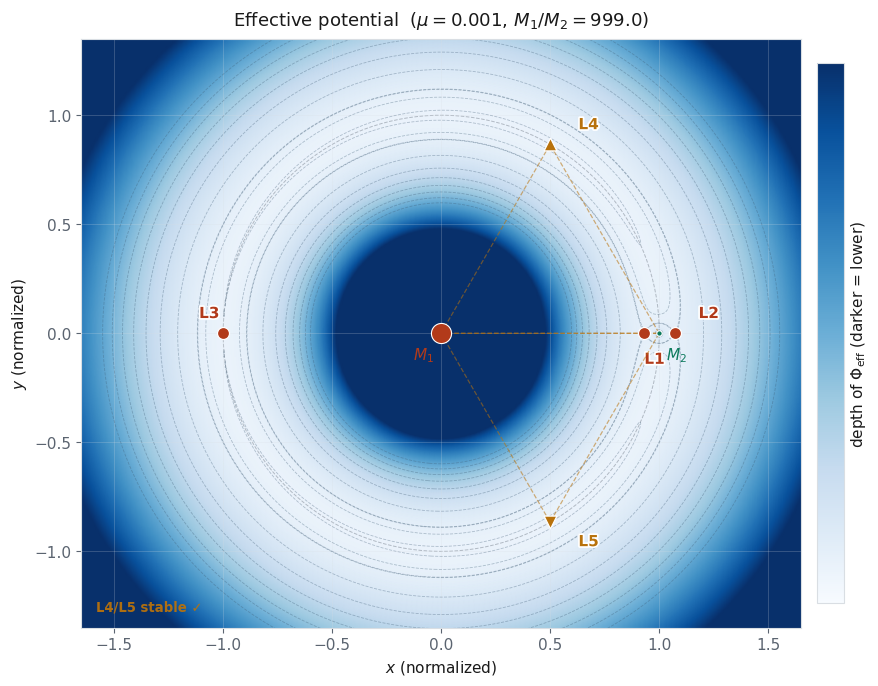

In [5]:
def plot_potential(mu=0.1, ax=None, title=None, colorbar=True):
    """Equipotential map of the effective potential."""
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(9, 7))

    N = 600
    xg = np.linspace(-1.7, 1.7, N)
    yg = np.linspace(-1.4, 1.4, N)
    X, Y = np.meshgrid(xg, yg)
    Z = phi_eff(X, Y, mu)

    pts = find_lagrange_points(mu)

    phi_L = {k: phi_eff(*pts[k], mu) for k in ['L1','L2','L3','L4','L5']}

    # Deeper (more negative) potential -> darker blue. Near the masses the
    # potential plunges to -infinity, so clip to keep the interesting
    # region (around the Lagrange points) visible instead of washed out.
    vmin = phi_L['L4'] - 0.4
    vmax = phi_L['L4'] + 0.05
    Zplot = np.clip(Z, vmin - 0.3, vmax)
    # invert so that LOW (more negative) potential maps to dark blue
    Zplot = vmax - Zplot

    im = ax.pcolormesh(X, Y, Zplot, cmap=POTENTIAL_CMAP, shading='gouraud',
                       vmin=0, vmax=(vmax - (vmin - 0.3)), rasterized=True)

    # Jacobi level curves -- darker blue-grey lines, visible on the light background
    phi_vals = sorted([phi_L[k] for k in ['L1','L2','L3','L4','L5']])
    extra = np.linspace(phi_L['L4'] - 0.35, phi_L['L5'] - 0.01, 8)
    levels = np.unique(np.concatenate([extra, phi_vals]))

    ax.contour(X, Y, Z, levels=levels, colors='#3D5A73', linewidths=0.6, alpha=0.35)

    # Hill curves through L1, L2, L3 (drawn thicker, warm color for contrast against blue)
    #for k, lw, alpha in [('L1', 1.3, 0.8), ('L2', 1.1, 0.7), ('L3', 0.9, 0.6)]:
    #    ax.contour(X, Y, Z, levels=[phi_L[k]], colors=[CORAL], linewidths=lw, alpha=alpha)

    # Hill curve through L4/L5
    #ax.contour(X, Y, Z, levels=[phi_L['L4']], colors=[AMBER], linewidths=1.5, alpha=0.85)

    theta = np.linspace(0, 2 * np.pi, 300)
    ax.plot(np.cos(theta), np.sin(theta), '--', color=MUTED, lw=0.7, alpha=0.4, zorder=1)

    m1_size = 180 * (1 - mu) + 30
    m2_size = 180 * mu + 15
    ax.scatter(*pts['M1'], s=m1_size, color=CORAL, zorder=6, ec='white', linewidths=0.8)
    ax.scatter(*pts['M2'], s=m2_size, color=TEAL,  zorder=6, ec='white', linewidths=0.8)
    ax.text(pts['M1'][0] - 0.08, pts['M1'][1] - 0.12, r'$M_1$', color=CORAL, fontsize=11, fontweight='bold', ha='center')
    ax.text(pts['M2'][0] + 0.08, pts['M2'][1] - 0.12, r'$M_2$', color=TEAL,  fontsize=11, fontweight='bold', ha='center')

    is_stable = mu < 0.03852
    lp_style = {
        'L1': (CORAL,  'o', 75, 'L1'),
        'L2': (CORAL,  'o', 75, 'L2'),
        'L3': (CORAL,  'o', 75, 'L3'),
        'L4': (AMBER if is_stable else MUTED, '^', 85, 'L4'),
        'L5': (AMBER if is_stable else MUTED, 'v', 85, 'L5'),
    }
    for name, (color, marker, size, label) in lp_style.items():
        p = pts[name]
        ax.scatter(*p, s=size, color=color, marker=marker, zorder=7, ec='white', linewidths=0.9)
        offset = {'L1': (0, -0.14), 'L2': (0.11, 0.07),
                  'L3': (-0.11, 0.07), 'L4': (0.13, 0.07), 'L5': (0.13, -0.11)}
        dx, dy = offset[name]
        txt = ax.text(p[0] + dx, p[1] + dy, label, color=color, fontsize=11, fontweight='bold')
        txt.set_path_effects([pe.withStroke(linewidth=2.5, foreground='white')])

    if is_stable:
        tri_x = [pts['M1'][0], pts['M2'][0], pts['L4'][0], pts['M1'][0]]
        tri_y = [pts['M1'][1], pts['M2'][1], pts['L4'][1], pts['M1'][1]]
        ax.plot(tri_x, tri_y, '--', color=AMBER, lw=0.9, alpha=0.55, zorder=3)
        tri_x2 = [pts['M1'][0], pts['M2'][0], pts['L5'][0], pts['M1'][0]]
        tri_y2 = [pts['M1'][1], pts['M2'][1], pts['L5'][1], pts['M1'][1]]
        ax.plot(tri_x2, tri_y2, '--', color=AMBER, lw=0.9, alpha=0.55, zorder=3)

    ax.set_xlim(-1.65, 1.65)
    ax.set_ylim(-1.35, 1.35)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.25)

    t = title or fr'Effective potential  ($\mu = {mu:.3f}$, $M_1/M_2 = {(1-mu)/mu:.1f}$)'
    ax.set_title(t, color=TEXT, fontsize=13, pad=10)
    ax.set_xlabel(r'$x$ (normalized)', fontsize=11)
    ax.set_ylabel(r'$y$ (normalized)', fontsize=11)

    stab_txt = 'L4/L5 stable \u2713' if is_stable else 'L4/L5 unstable \u2717'
    stab_col = AMBER if is_stable else MUTED
    ax.text(0.02, 0.03, stab_txt, transform=ax.transAxes, color=stab_col, fontsize=9.5,
            fontweight='bold', alpha=0.95)

    if colorbar and standalone:
        cb = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
        cb.set_label(r'depth of $\Phi_{\rm eff}$ (darker = lower)', color=TEXT)
        cb.ax.yaxis.set_tick_params(color=MUTED)
        cb.set_ticks([])
        plt.setp(cb.ax.yaxis.get_ticklabels(), color=MUTED)

    if standalone:
        plt.tight_layout()
        plt.show()

    return im


plot_potential(mu=0.001)

## 3  Exercise

Plot and compare: Sun-Earth, Sun-Jupiter, Earth-Moon systems.

In [7]:
#def plot_systems():
    

#plot_systems()

## 4  Potential along the x-axis

1D slice through $\Phi_{\rm eff}$ at $y=0$: the three local extrema at L1, L2, L3 are clearly visible.

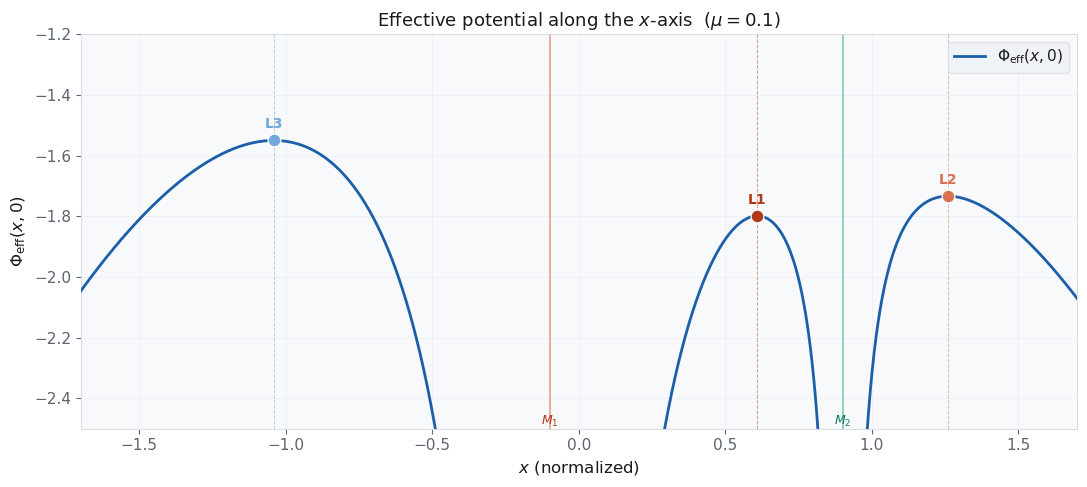

In [8]:
def plot_xaxis_potential(mu=0.1):
    pts = find_lagrange_points(mu)
    x   = np.linspace(-1.7, 1.7, 2000)

    mask = (np.abs(x - (-mu)) > 0.04) & (np.abs(x - (1 - mu)) > 0.04)
    xm   = x[mask]
    phi  = phi_eff(xm, 0, mu)

    fig, ax = plt.subplots(figsize=(11, 5))

    ax.plot(xm, phi, color=BLUE, lw=2.0, zorder=3, label=r'$\Phi_{\rm eff}(x, 0)$')

    lp_col = {'L1': CORAL, 'L2': CORAL_L, 'L3': BLUE_L}
    for name, col in lp_col.items():
        px = pts[name][0]
        py = phi_eff(px, 0, mu)
        ax.scatter(px, py, s=85, color=col, zorder=6, ec='white', linewidths=0.9)
        ax.text(px, py + 0.04, name, color=col, fontsize=10, ha='center', fontweight='bold')
        ax.axvline(px, color=col, lw=0.7, ls='--', alpha=0.5)

    ax.axvline(-mu,     color=CORAL_L, lw=1.1, alpha=0.7)
    ax.axvline(1 - mu,  color=TEAL_L,  lw=1.1, alpha=0.7)
    ax.text(-mu,    ax.get_ylim()[0] if ax.get_ylim()[0] > -3 else -2.5, r'$M_1$', color=CORAL, ha='center', fontsize=9, va='bottom', fontweight='bold')
    ax.text(1 - mu, ax.get_ylim()[0] if ax.get_ylim()[0] > -3 else -2.5, r'$M_2$', color=TEAL,  ha='center', fontsize=9, va='bottom', fontweight='bold')

    ax.set_ylim(-2.5, -1.2)
    ax.set_xlim(-1.7, 1.7)
    ax.set_xlabel(r'$x$ (normalized)', fontsize=12)
    ax.set_ylabel(r'$\Phi_{\rm eff}(x, 0)$', fontsize=12)
    ax.set_title(fr'Effective potential along the $x$-axis  ($\mu = {mu}$)', color=TEXT, fontsize=13)
    ax.legend(fontsize=11, facecolor=CARD_BG, edgecolor=GRID, labelcolor=TEXT)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_xaxis_potential(mu=0.1)
# plot_xaxis_potential(mu=0.001)   # Sun-Earth-like
# plot_xaxis_potential(mu=0.3)     # near-equal masses

## 5  Interactive exploration 

Slider for $\mu$  
*(If the widgets don't render try: `jupyter nbextension enable --py widgetsnbextension`)*

In [10]:
try:
    import ipywidgets as widgets
    from IPython.display import display

    def interactive_plot(mu=0.1, plot_type='Equipotential map'):
        if plot_type == 'Equipotential map':
            plot_potential(mu=mu)
        elif plot_type == 'x-axis slice':
            plot_xaxis_potential(mu=mu)
        pts = find_lagrange_points(mu)
        print(f"\n  \u03bc = {mu:.4f}   |   M\u2081/M\u2082 = {(1-mu)/mu:.1f}   |   "
              f"Routh criterion: {'stable' if mu < 0.03852 else 'unstable'}")
        print(f"  L1 = ({pts['L1'][0]:+.4f}, 0)   "
              f"L2 = ({pts['L2'][0]:+.4f}, 0)   "
              f"L3 = ({pts['L3'][0]:+.4f}, 0)")
        print(f"  L4 = ({pts['L4'][0]:+.4f}, {pts['L4'][1]:+.4f})   "
              f"L5 = ({pts['L5'][0]:+.4f}, {pts['L5'][1]:+.4f})")

    mu_slider = widgets.FloatSlider(
        value=0.1, min=0.001, max=0.499, step=0.001,
        description='\u03bc:', continuous_update=False,
        style={'description_width': '30px'},
        layout=widgets.Layout(width='500px')
    )
    type_toggle = widgets.ToggleButtons(
        options=['Equipotential map', 'x-axis slice'],
        description='View:',
        style={'description_width': '70px'}
    )

    presets = widgets.ToggleButtons(
        options=[
            ('Sun-Earth', 0.000003),
            ('Sun-Jupiter', 0.00095),
            ('Earth-Moon', 0.01215),
            ('Routh boundary', 0.03852),
            ('Equal masses', 0.5),
        ],
        description='Preset:',
        style={'description_width': '70px'}
    )

    def on_preset_change(change):
        mu_slider.value = change['new']

    presets.observe(on_preset_change, names='value')

    out = widgets.interactive_output(
        interactive_plot,
        {'mu': mu_slider, 'plot_type': type_toggle}
    )

    display(widgets.VBox([
        widgets.HTML('<b style="color:#9FE1CB">Preset systems:</b>'),
        presets,
        widgets.HTML('<b style="color:#9FE1CB">Manual setting:</b>'),
        widgets.HBox([mu_slider, type_toggle]),
        out
    ]))

except ImportError:
    print("ipywidgets not available -- use the static plots in the cells above.")
    plot_potential(mu=0.1)

---
## Summary

| Point | Position | Stability |
|-------|----------|------------|
| L1 | between $M_1$ and $M_2$ | unstable (saddle point) |
| L2 | beyond $M_2$ | unstable (saddle point) |
| L3 | beyond $M_1$ | unstable (saddle point) |
| L4 | ahead of $M_2$ | stable if $\mu < 0.0385$ |
| L5 | behind $M_2$ | stable if $\mu < 0.0385$ |
